# OpenAI互換VLMによる物体検出

このNotebookでは、OpenAI互換のChat Completions APIに画像を渡し、画像内の主要物体をバウンディングボックスで可視化します。

> **注意**: VLMが返す座標とconfidenceは専用の物体検出モデルによる値ではありません。confidenceは参考値としてのみ利用してください。

## 1. ライブラリのインポート

In [1]:
import base64
import json
import mimetypes
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image, ImageDraw, ImageFont

## 2. APIと入力画像の設定

以下の環境変数を設定してから実行してください: `VLM_API_KEY`、`VLM_BASE_URL`、`VLM_MODEL`。

モデル: gpt-5.6-luna
画像サイズ: 1448 x 1086


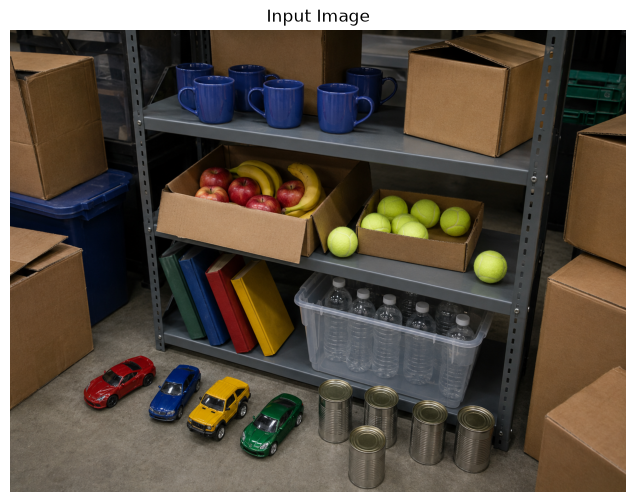

In [2]:
load_dotenv(dotenv_path=Path(".env"), override=False)

api_key = os.environ.get("VLM_API_KEY")
base_url = os.environ.get("VLM_BASE_URL")
model_name = os.environ.get("VLM_MODEL")

missing = [
    name
    for name, value in {
        "VLM_API_KEY": api_key,
        "VLM_MODEL": model_name,
    }.items()
    if not value
]
if missing:
    raise EnvironmentError(
        "環境変数が未設定です: " + ", ".join(missing) +
        "。README.md の API設定 を確認してください。"
    )

client = OpenAI(api_key=api_key)
image_path = Path("../assets/test1.png")
if not image_path.is_file():
    raise FileNotFoundError(f"入力画像が見つかりません: {image_path.resolve()}")

image = Image.open(image_path).convert("RGB")
print(f"モデル: {model_name}")
print(f"画像サイズ: {image.size[0]} x {image.size[1]}")
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

## 3. VLMに物体検出を依頼

座標は画像幅・高さをそれぞれ1000とした正規化座標で返させます。API実装ごとの構造化出力対応に依存しないよう、JSONのみを返すようプロンプトで指定します。

In [3]:
mime_type = mimetypes.guess_type(image_path.name)[0] or "image/png"
image_base64 = base64.b64encode(image_path.read_bytes()).decode("ascii")
image_url = f"data:{mime_type};base64,{image_base64}"

system_prompt = """
あなたは画像内の物体を検出するアシスタントです。
画像内で視認できる主要な物体をできる限り網羅し、同じ物体を重複して返さないでください。
各物体について、意味の分かる短いラベル、0から1の参考confidence、物体を囲む矩形を返してください。
矩形は画像の幅と高さをそれぞれ1000とする正規化座標 [x1, y1, x2, y2] です。
返答は説明・Markdown・コードフェンスを含めず、必ず次のJSONオブジェクトだけにしてください。
{"detections":[{"label":"object name","confidence":0.0,"bbox_1000":[0,0,0,0]}]}
物体が見つからない場合は {"detections":[]} を返してください。
"""

try:
    completion = client.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "system", "content": system_prompt},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "この画像を検出してください。"},
                    {"type": "image_url", "image_url": {"url": image_url}},
                ],
            },
        ],
    )
except Exception as error:
    print(error)
    raise RuntimeError(
        "VLM APIの呼び出しに失敗しました。URL・モデル名・認証情報と、画像入力対応を確認してください。"
    ) from error

raw_response = completion.choices[0].message.content or ""
print(raw_response)

{"detections":[{"label":"金属製ラック","confidence":0.99,"bbox_1000":[190,0,846,912]},{"label":"段ボール箱","confidence":0.97,"bbox_1000":[0,47,160,374]},{"label":"段ボール箱","confidence":0.96,"bbox_1000":[0,431,140,826]},{"label":"段ボール箱","confidence":0.97,"bbox_1000":[370,0,568,190]},{"label":"段ボール箱","confidence":0.98,"bbox_1000":[648,7,841,274]},{"label":"段ボール箱","confidence":0.96,"bbox_1000":[900,183,1000,515]},{"label":"段ボール箱","confidence":0.96,"bbox_1000":[861,545,1000,1000]},{"label":"青い収納ボックス","confidence":0.98,"bbox_1000":[0,299,209,661]},{"label":"青いマグカップ","confidence":0.97,"bbox_1000":[265,72,332,204]},{"label":"青いマグカップ","confidence":0.97,"bbox_1000":[355,75,432,181]},{"label":"青いマグカップ","confidence":0.98,"bbox_1000":[300,98,369,206]},{"label":"青いマグカップ","confidence":0.98,"bbox_1000":[390,106,476,214]},{"label":"青いマグカップ","confidence":0.98,"bbox_1000":[500,112,595,225]},{"label":"青いマグカップ","confidence":0.97,"bbox_1000":[567,80,635,179]},{"label":"りんご","confidence":0.93,"bbox_1000":[304,296,359,3

## 4. 応答の検証とピクセル座標への変換

In [4]:
def parse_detection_response(text):
    fenced = re.search(r"```(?:json)?\s*(.*?)```", text, flags=re.DOTALL | re.IGNORECASE)
    candidate = fenced.group(1) if fenced else text
    if not fenced:
        start, end = candidate.find("{"), candidate.rfind("}")
        candidate = candidate[start:end + 1] if start >= 0 and end >= start else candidate
    try:
        payload = json.loads(candidate.strip())
    except json.JSONDecodeError as error:
        raise ValueError("VLMの応答をJSONとして解釈できません。上の応答を確認してください。") from error
    if not isinstance(payload, dict) or not isinstance(payload.get("detections"), list):
        raise ValueError("VLM応答には detections 配列が必要です。")
    return payload["detections"]

def normalize_detections(raw_detections, image_width, image_height):
    valid = []
    for index, item in enumerate(raw_detections):
        if not isinstance(item, dict):
            print(f"検出 {index} を無視しました: オブジェクトではありません。")
            continue
        label = str(item.get("label", "")).strip()
        bbox = item.get("bbox_1000")
        try:
            values = [float(value) for value in bbox]
            if len(values) != 4 or not label:
                raise ValueError
        except (TypeError, ValueError):
            print(f"検出 {index} を無視しました: label または bbox_1000 が不正です。")
            continue
        x1, y1, x2, y2 = [max(0.0, min(1000.0, value)) for value in values]
        x1, x2 = sorted((x1, x2))
        y1, y2 = sorted((y1, y2))
        if x1 == x2 or y1 == y2:
            print(f"検出 {index} を無視しました: 面積が0の矩形です。")
            continue
        try:
            confidence = float(item.get("confidence", 0.0))
        except (TypeError, ValueError):
            confidence = 0.0
        valid.append({
            "label": label,
            "confidence": max(0.0, min(1.0, confidence)),
            "x1": round(x1 / 1000 * image_width, 1),
            "y1": round(y1 / 1000 * image_height, 1),
            "x2": round(x2 / 1000 * image_width, 1),
            "y2": round(y2 / 1000 * image_height, 1),
        })
    return valid

raw_detections = parse_detection_response(raw_response)
detections = normalize_detections(raw_detections, *image.size)
print(f"有効な検出数: {len(detections)}")

有効な検出数: 48


## 5. 検出結果の可視化と集計

confidenceはVLMの参考値です。しきい値による自動除外は行わず、結果を目視で確認してください。

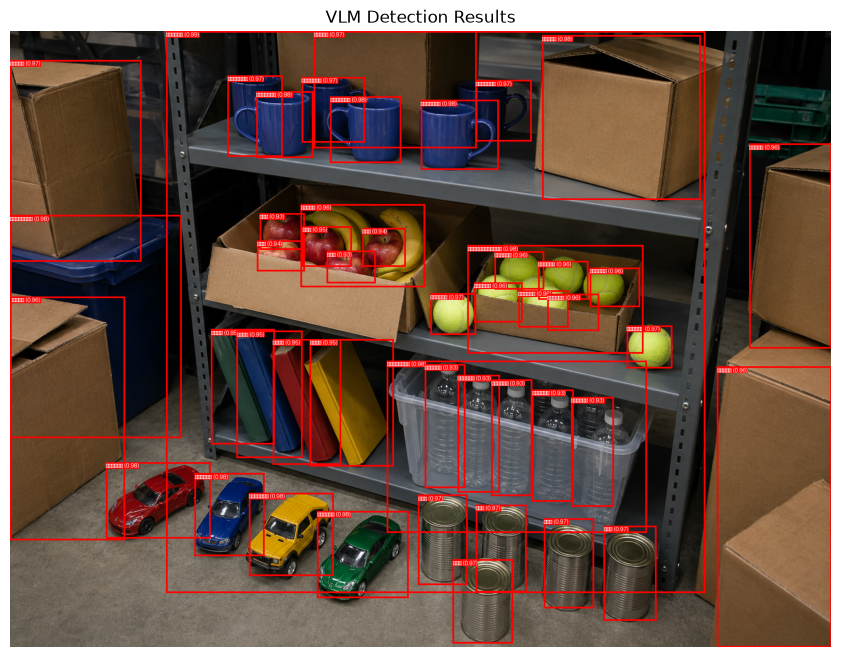

,label,confidence,x1,y1,x2,y2
0,金属製ラック,0.99,275.1,0.0,1225.0,990.4
1,段ボール箱,0.97,0.0,51.0,231.7,406.2
2,段ボール箱,0.96,0.0,468.1,202.7,897.0
3,段ボール箱,0.97,535.8,0.0,822.5,206.3
4,段ボール箱,0.98,938.3,7.6,1217.8,297.6
5,段ボール箱,0.96,1303.2,198.7,1448.0,559.3
6,段ボール箱,0.96,1246.7,591.9,1448.0,1086.0
7,青い収納ボックス,0.98,0.0,324.7,302.6,717.8
8,青いマグカップ,0.97,383.7,78.2,480.7,221.5
9,青いマグカップ,0.97,514.0,81.5,625.5,196.6


ラベル別の検出数


,label,検出数
0,テニスボール,8
1,青いマグカップ,6
2,段ボール箱,6
3,金属缶,5
4,りんご,5
5,ペットボトル,5
6,テニスボール用段ボール箱,1
7,緑色の本,1
8,赤いミニカー,1
9,バナナの房,1


In [5]:
annotated = image.copy()
draw = ImageDraw.Draw(annotated)
font = ImageFont.load_default()

for detection in detections:
    x1, y1, x2, y2 = (detection[key] for key in ("x1", "y1", "x2", "y2"))
    draw.rectangle((x1, y1, x2, y2), outline="red", width=3)
    text = f"{detection['label']} ({detection['confidence']:.2f})"
    text_box = draw.textbbox((x1, y1), text, font=font)
    draw.rectangle(text_box, fill="red")
    draw.text((x1, y1), text, fill="white", font=font)

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("VLM Detection Results")
plt.show()

df = pd.DataFrame(detections, columns=["label", "confidence", "x1", "y1", "x2", "y2"])
display(df)

if df.empty:
    print("有効な検出結果はありません。")
else:
    counts = df.groupby("label").size().sort_values(ascending=False).rename("検出数").reset_index()
    print("ラベル別の検出数")
    display(counts)